In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
checkpoint_path = "checkpoints/model-{epoch:02d}-{val_loss:.2f}.hdf5"

# Create a ModelCheckpoint callback
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',  # Metric to monitor
    verbose=1,           # Output verbose messages
    save_best_only=True, # Save only the best model
    save_weights_only=False, # Save the entire model, not just weights
    mode='min',          # Minimize the monitored metric (for val_loss)
    save_freq='epoch'    # Save the model after every epoch
)



In [ ]:
import os

def walk_through_dir(dir_path):
  """Walks through the directory and returns it's content"""
  for dir_path, dirname, filenames in os.walk(dir_path):
    print(f"There are {len(dirname)} directories and {len(filenames)} images in {dir_path}")

walk_through_dir("D:/Birds_data")

There are 2 directories and 1 images in D:/Birds_data
There are 62 directories and 0 images in D:/Birds_data\TEST
There are 0 directories and 112 images in D:/Birds_data\TEST\Alexandrine_Parakeet
There are 0 directories and 91 images in D:/Birds_data\TEST\Bar_headed_Goose
There are 0 directories and 104 images in D:/Birds_data\TEST\Baya_Weaver
There are 0 directories and 91 images in D:/Birds_data\TEST\Black_breasted_Weaver
There are 0 directories and 94 images in D:/Birds_data\TEST\Black_Bulbul
There are 0 directories and 84 images in D:/Birds_data\TEST\Black_Crowned_Night_Heron
There are 0 directories and 98 images in D:/Birds_data\TEST\Black_Drongo
There are 0 directories and 112 images in D:/Birds_data\TEST\Black_Kite
There are 0 directories and 117 images in D:/Birds_data\TEST\Black_Throated_Thrush
There are 0 directories and 91 images in D:/Birds_data\TEST\Blue_Tailed_Bee_Eater
There are 0 directories and 140 images in D:/Birds_data\TEST\Bronze_Winged_Jacana
There are 0 directori

In [ ]:
from pathlib import Path
import os
from PIL import Image
import random
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "D:/Birds_data"

random.seed(42)


image_path_list = list(Path(IMAGE_PATH).glob("*/*/*"))
rand_image = random.choice(image_path_list)


image_class = rand_image.parent.stem

print(image_class)


img = Image.open(rand_image)

print(f"The image path is {rand_image} and the width and height are {img.width} {img.height}")

img.show()

Northern_Lapwing
The image path is D:\Birds_data\TRAIN\Northern_Lapwing\NL_(1559).jpg and the width and height are 217 232


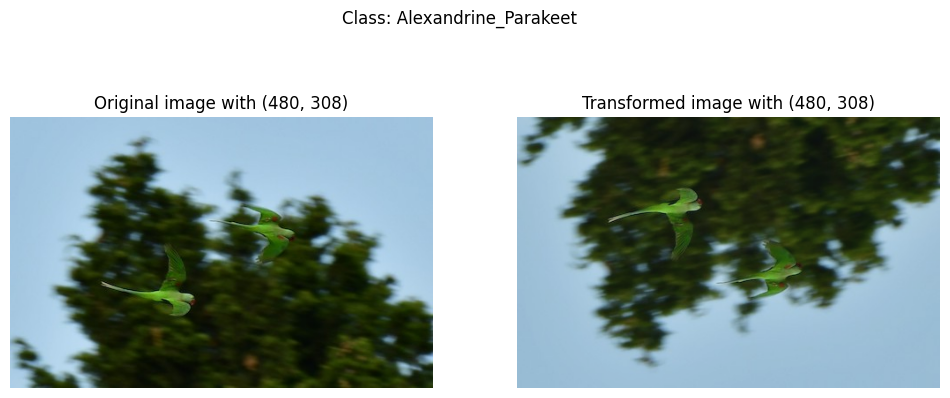

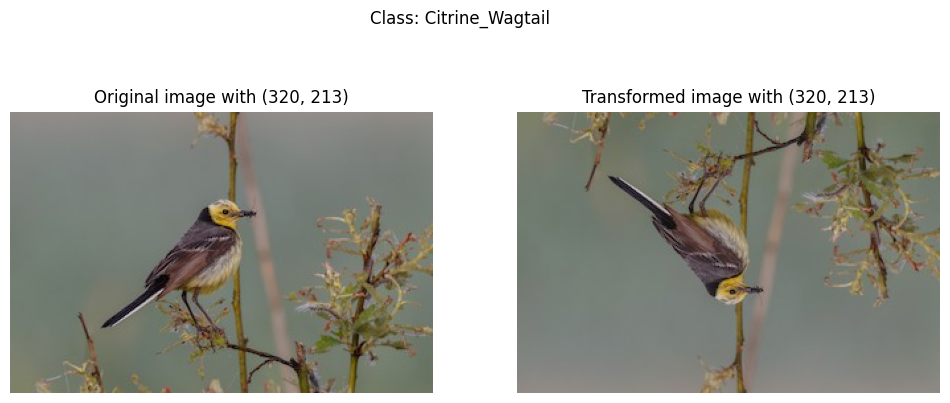

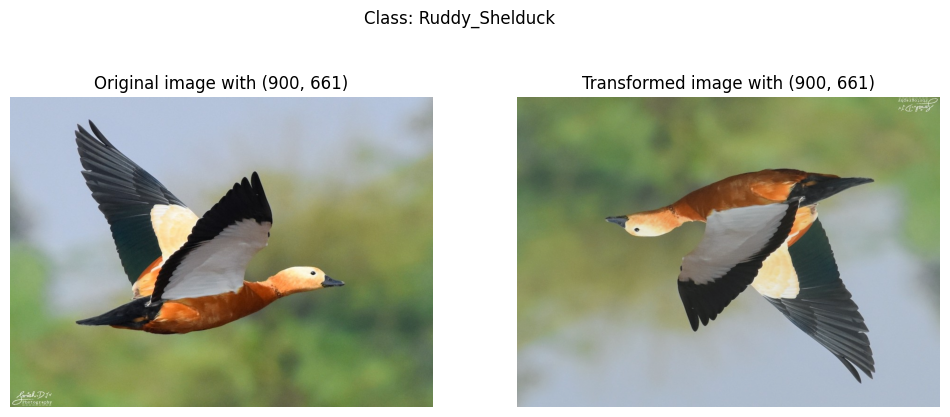

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

def apply_random_augmentation(image):
    # Convert PIL image to a TensorFlow tensor
    image = tf.convert_to_tensor(np.array(image), dtype=tf.float32)
    # Randomly apply a combination of augmentations to the image
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Convert back to PIL image
    image = tf.cast(image, tf.uint8).numpy()
    return Image.fromarray(image)

def plot_transformed_image(img_path, transform, n=9, seed=42):
    """Selects the random images and plots them with original respect to the transformed one as well"""

    random_image_paths = random.sample(img_path, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original image with {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed image with {transformed_image.size}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}")
            plt.show()

# Sample image paths (adjust as needed)
image_path_list = list(Path(IMAGE_PATH).glob("*/*/*"))

plot_transformed_image(img_path=image_path_list, transform=apply_random_augmentation, n=3, seed=42)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_directory = 'D:\Birds_Final\train'
validation_directory = 'D:\Birds_Final\test'
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)


image_size = (256, 256)


batch_size = 8



datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rescale = 1./255)

train_generator = datagen.flow_from_directory(
    train_directory,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)


validation_generator = datagen.flow_from_directory(
    validation_directory,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)





Found 45084 images belonging to 62 classes.
Found 6849 images belonging to 62 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras import layers, models, regularizers

image_size = (256, 256)
print("Image size:", image_size)

base_model = DenseNet121(include_top=False, input_shape=(256, 256, 3))
print("Base model input shape:", base_model.input_shape)
print("Base model output shape:", base_model.output_shape)

model_dense = models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(image_size[0], image_size[1], 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    #layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # L2 regularization added here
    # layers.Dropout(0.5),
    layers.Dense(62, activation='softmax')
])

model_dense.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

model_dense.summary()


Image size: (256, 256)
Base model input shape: (None, 256, 256, 3)
Base model output shape: (None, 8, 8, 1024)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 8, 8, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 62)                63550     
                                                                 
Total params: 7,101,054
Trainable params: 7,017,406
Non-trainable params: 83,648
_________________________________________________________________


In [ ]:
model_dense.save_weights('D:/Birds_data/model_weights.weights.h5')

In [ ]:
model_dense.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callback = keras.callbacks.EarlyStopping(monitor='loss',
                                              patience=15)

In [ ]:
epochs = 100
densenet_history = model_dense.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint,callback]
)

Epoch 1/100
5636/5636 [==============================] - ETA: 0s - loss: 0.9163 - accuracy: 0.7608
Epoch 1: val_loss improved from inf to 0.78331, saving model to checkpoints\model-01-0.78.hdf5
5636/5636 [==============================] - 1677s 296ms/step - loss: 0.9163 - accuracy: 0.7608 - val_loss: 0.7833 - val_accuracy: 0.7960
Epoch 2/100
5636/5636 [==============================] - ETA: 0s - loss: 0.3953 - accuracy: 0.8841
Epoch 2: val_loss improved from 0.78331 to 0.65017, saving model to checkpoints\model-02-0.65.hdf5
5636/5636 [==============================] - 845s 150ms/step - loss: 0.3953 - accuracy: 0.8841 - val_loss: 0.6502 - val_accuracy: 0.8457
Epoch 3/100
5636/5636 [==============================] - ETA: 0s - loss: 0.2760 - accuracy: 0.9166
Epoch 3: val_loss improved from 0.65017 to 0.63922, saving model to checkpoints\model-03-0.64.hdf5
5636/5636 [==============================] - 749s 133ms/step - loss: 0.2760 - accuracy: 0.9166 - val_loss: 0.6392 - val_accuracy: 0.851

In [ ]:
model_dense.save('densenetmodel_100e7.h5')
print("Model saved successfully")

Model saved successfully


In [ ]:
validation_generator.reset()

In [ ]:
predicted_labels = []
true_labels = []

In [ ]:
# model1 = keras.models.load_model('D:/rubinHood/checkpoints/model-03-0.64.hdf5')

In [ ]:
model1 = keras.models.load_model('D:/rubinHood/densenetmodel_100e7.h5')

In [ ]:
for i in range(validation_generator.samples // validation_generator.batch_size + 1):
    images, labels = validation_generator.next()
    predictions = model1.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    predicted_labels.extend([key for key, value in validation_generator.class_indices.items() if value == class_idx][0] for class_idx in predicted_classes)
    true_labels.extend([key for key, value in validation_generator.class_indices.items() if value == np.argmax(labels[idx])] for idx in range(len(labels)))


1/1 [==============================] - 0s 24ms/step


In [ ]:
true_labels = [label[0] for label in true_labels]

In [ ]:
true_label= [validation_generator.class_indices[label] for label in true_labels]
predicted_label = [validation_generator.class_indices[label] for label in predicted_labels]

In [ ]:
print("Predicted Labels:", predicted_label)
print("True Labels:", true_label)

Predicted Labels: [49, 3, 49, 32, 27, 6, 4, 43, 61, 23, 39, 5, 15, 27, 26, 42, 60, 1, 19, 7, 19, 2, 10, 20, 16, 3, 17, 11, 53, 33, 20, 31, 15, 45, 7, 12, 46, 41, 45, 13, 27, 0, 51, 20, 12, 25, 9, 20, 6, 8, 10, 28, 45, 25, 5, 36, 9, 12, 39, 61, 8, 9, 21, 56, 4, 7, 10, 22, 19, 59, 27, 14, 50, 12, 47, 23, 10, 17, 19, 19, 2, 31, 12, 50, 33, 29, 43, 9, 12, 14, 55, 4, 59, 17, 9, 39, 50, 13, 1, 57, 28, 40, 40, 57, 44, 49, 22, 18, 14, 18, 42, 26, 18, 9, 24, 35, 40, 14, 45, 21, 12, 17, 37, 2, 45, 45, 55, 18, 21, 34, 50, 51, 61, 31, 56, 51, 51, 10, 41, 15, 47, 46, 61, 48, 6, 53, 28, 1, 19, 57, 16, 16, 16, 6, 32, 2, 12, 2, 11, 61, 54, 27, 56, 48, 20, 44, 7, 38, 50, 19, 19, 50, 15, 1, 18, 39, 33, 33, 12, 49, 21, 12, 40, 40, 14, 39, 5, 61, 40, 40, 50, 0, 55, 2, 25, 18, 17, 16, 8, 7, 56, 20, 19, 6, 40, 33, 45, 61, 5, 9, 13, 51, 32, 36, 22, 28, 3, 16, 36, 30, 44, 10, 43, 23, 44, 56, 50, 32, 17, 40, 2, 26, 33, 33, 45, 33, 0, 50, 12, 19, 55, 59, 44, 34, 3, 28, 37, 19, 7, 8, 21, 38, 50, 28, 59, 19, 51, 

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def calculate_auc_scores(true_labels, predicted_probabilities, num_classes):
    auc_scores = []

    for class_index in range(num_classes):
        binary_true_labels = np.where(true_labels == class_index, 1, 0)
        predicted_scores = predicted_probabilities[:, class_index]

        auc = roc_auc_score(binary_true_labels, predicted_scores)
        auc_scores.append(auc)

    average_auc_score = np.mean(auc_scores)

    return auc_scores, average_auc_score

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Example true labels and predicted labels
true_labels = np.array(true_label)  # Replace with your true labels
predicted_labels = np.array(predicted_label)  # Replace with your predicted labels

# Calculate the AUC score for each class
auc_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Check if only one instance of the class is present
    if np.sum(binary_true_labels) == 1 or np.sum(binary_predicted_labels) == 1:
        auc = np.nan  # Set AUC score as NaN
    else:
        # Calculate the AUC score for the current class
        auc = roc_auc_score(binary_true_labels, binary_predicted_labels)
    auc_scores.append(auc)

# Calculate the average AUC score
average_auc_score = np.nanmean(auc_scores)

print("AUC Scores for each class:")
print(auc_scores)
print("Average AUC Score:", average_auc_score)

AUC Scores for each class:
[0.9898097393922687, 0.9663670895544231, 0.9360174203113417, 0.9039592421689213, 0.9043184457818604, 0.9016540255563046, 0.8839285714285714, 0.9430332739156269, 0.9714176767298993, 0.983220537970464, 0.9950870898366799, 0.9758948368704466, 0.9959708160611684, 0.9999260901699927, 0.9579637841832963, 0.9272114851056342, 0.9708114645226795, 0.9877995987752086, 0.994628640656678, 0.9468145484249108, 0.9431312990058179, 0.8978486960194277, 0.8683824305775526, 0.9522331327209376, 0.7964364903389295, 0.9521866162733037, 0.9622089256626685, 0.9947916666666667, 0.9457633829585048, 0.9573725055432372, 0.9043045705279747, 0.9542477025728477, 0.9151858433288909, 0.8872899454560039, 0.9716319905562933, 0.9608891847906496, 0.9898989898989898, 0.9435340233878856, 0.9539473684210527, 0.9053330689928628]
Average AUC Score: 0.9448113052779219


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Example true labels and predicted labels
true_labels = np.array(true_label)  # Replace with your true labels
predicted_labels = np.array(predicted_label)  # Replace with your predicted labels

# Calculate the F1 score for each class
f1_scores = []
for class_index in range(40):
    # Create binary labels for the current class
    binary_true_labels = np.where(true_labels == class_index, 1, 0)
    binary_predicted_labels = np.where(predicted_labels == class_index, 1, 0)

    # Calculate the F1 score for the current class
    f1 = f1_score(binary_true_labels, binary_predicted_labels)
    f1_scores.append(f1)

# Calculate the average F1 score
average_f1_score = np.mean(f1_scores)

print("F1 Scores for each class:")
print(f1_scores)
print("Average F1 Score:", average_f1_score)

F1 Scores for each class:
[0.9205020920502092, 0.918918918918919, 0.8465116279069768, 0.8735632183908046, 0.8607594936708861, 0.8061224489795918, 0.8686868686868687, 0.8666666666666667, 0.8958333333333334, 0.9617486338797814, 0.936026936026936, 0.9523809523809523, 0.981549815498155, 0.9940828402366864, 0.927710843373494, 0.8828125, 0.9343434343434344, 0.9647058823529412, 0.9511111111111111, 0.9189985272459499, 0.8181818181818182, 0.8170731707317073, 0.8, 0.9382716049382716, 0.6666666666666666, 0.759493670886076, 0.8768472906403941, 0.9947643979057592, 0.8928571428571429, 0.8850574712643678, 0.6984126984126984, 0.9375, 0.8163265306122449, 0.8514056224899599, 0.918918918918919, 0.9431818181818182, 0.9897959183673469, 0.9169675090252708, 0.9517241379310345, 0.8300653594771242]
Average F1 Score: 0.8891636973135579


6849


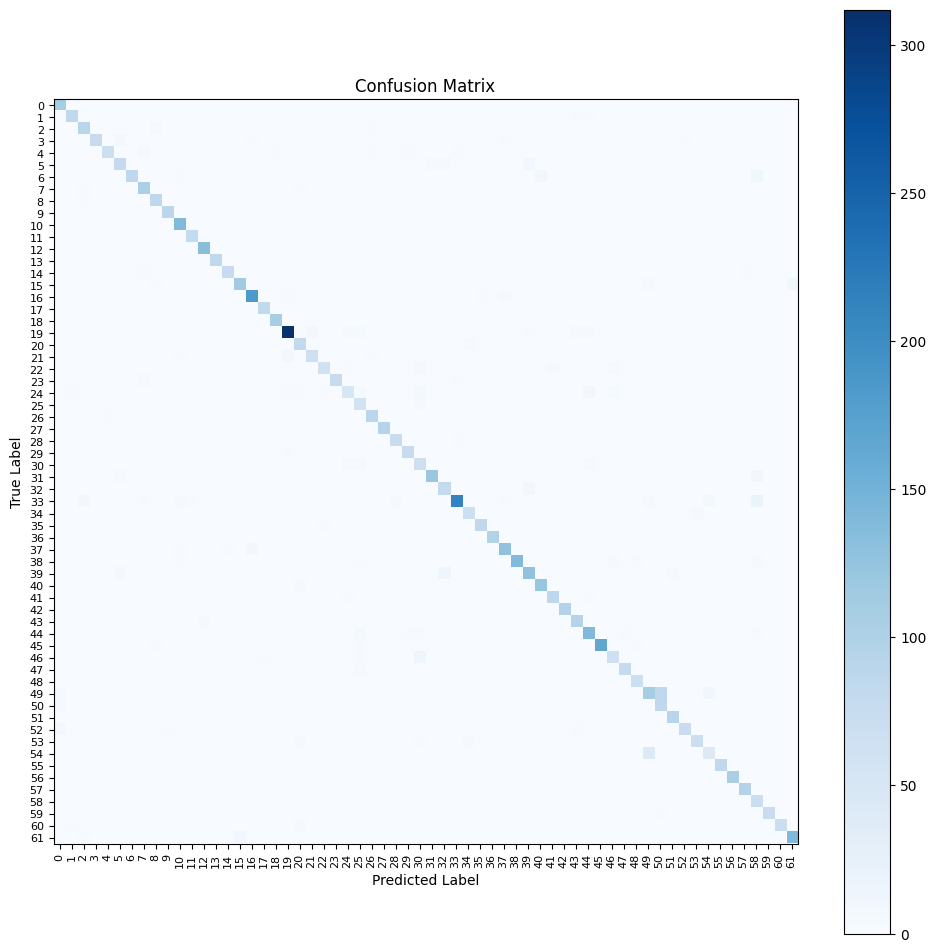

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

print(len(true_labels))

y_true = np.array(true_label)
y_pred = np.array(predicted_label)

y_true, y_pred
# convert numpy arrays to PyTorch tensors
y_true_t = tf.cast(y_true, dtype='float32')
y_pred_t = tf.cast(y_pred, dtype='float32')


# compute confusion matrix
cm = confusion_matrix(y_true_t, y_pred)

# plot confusion matrix
plt.figure(figsize=(12,12))

plt.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_true)))
plt.xticks(np.arange(len(np.unique(y_true))), labels=np.unique(y_true), rotation=90)
plt.yticks(np.arange(len(np.unique(y_true))), labels=np.unique(y_true))

plt.tick_params(axis='both', which='major', labelsize=8)

# plt.grid(visible=True, which='both', axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
keras_file = 'densenetmodel_100e7.h5'
keras.models.save_model(model1, keras_file)

converter = tf.lite.TFLiteConverter.from_keras_model(model1)
tflite_model = converter.convert()
open('densenet121.tflite','wb').write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdciufvwn\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdciufvwn\assets


28157172